In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [1]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Save class names BEFORE prefetching
CLASS_NAMES = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 285 files belonging to 2 classes.
Found 48 files belonging to 2 classes.
Found 24 files belonging to 2 classes.


Classes: ['fresh', 'rotten']
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambd  (None, 224, 224, 3)       0         
 a)                                                              
                                                                 
 tf.math.subtract (TFOpLamb  (None, 224, 224, 3)       0         
 da)                                                             
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                

C:\Users\Sai Manikanta\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


9/9 [==============================] - 9s 777ms/step - loss: 0.6579 - accuracy: 0.6561 - val_loss: 0.4777 - val_accuracy: 0.7500 - lr: 0.0010
Epoch 2/5
9/9 [==============================] - ETA: 0s - loss: 0.4704 - accuracy: 0.7860
Epoch 2: val_accuracy improved from 0.75000 to 0.81250, saving model to models\fruit_quality_model.h5
9/9 [==============================] - 7s 840ms/step - loss: 0.4704 - accuracy: 0.7860 - val_loss: 0.3985 - val_accuracy: 0.8125 - lr: 0.0010
Epoch 3/5
9/9 [==============================] - ETA: 0s - loss: 0.3538 - accuracy: 0.8456
Epoch 3: val_accuracy improved from 0.81250 to 0.87500, saving model to models\fruit_quality_model.h5
9/9 [==============================] - 8s 916ms/step - loss: 0.3538 - accuracy: 0.8456 - val_loss: 0.3498 - val_accuracy: 0.8750 - lr: 0.0010
Epoch 4/5
9/9 [==============================] - ETA: 0s - loss: 0.3127 - accuracy: 0.8667
Epoch 4: val_accuracy did not improve from 0.87500
9/9 [==============================] - 7s 802m

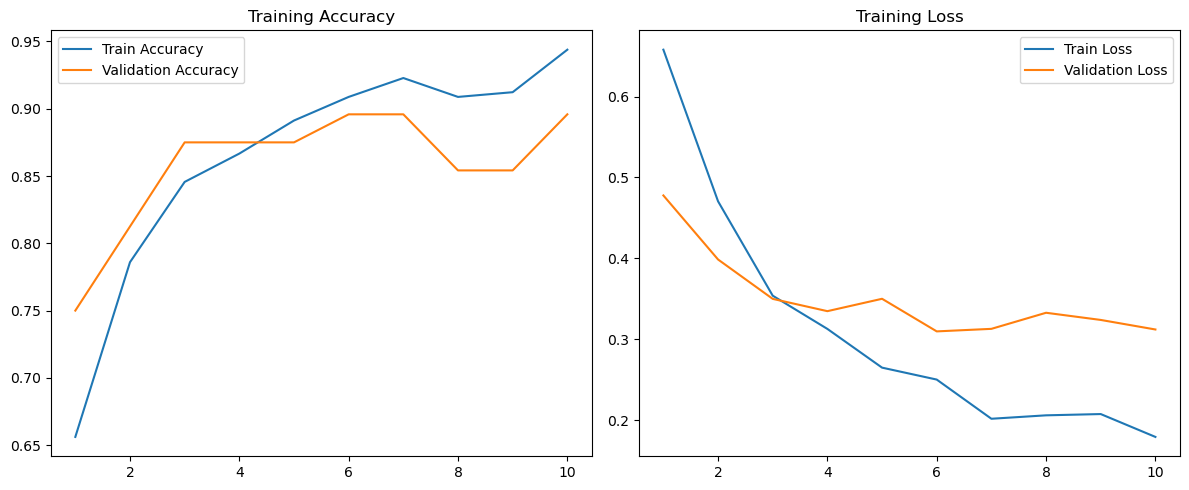


Training Completed Successfully.


In [2]:
# train.py

import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)



# =====================================================
# Configuration
# =====================================================

IMG_HEIGHT = 224
IMG_WIDTH = 224
EPOCHS = 5

MODEL_DIR = "models"
RESULT_DIR = "results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "fruit_quality_model.h5")

NUM_CLASSES = len(CLASS_NAMES)



print("Classes:", CLASS_NAMES)

# =====================================================
# Data Augmentation
# =====================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# =====================================================
# Build Model
# =====================================================

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =====================================================
# Callbacks
# =====================================================

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    ),

    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(
        os.path.join(RESULT_DIR, "training_log.csv")
    )

]

# =====================================================
# Initial Training
# =====================================================

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks

)

# =====================================================
# Fine Tuning
# =====================================================

print("\nStarting Fine-Tuning...\n")

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

history_fine = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    callbacks=callbacks

)

# =====================================================
# Save Final Model
# =====================================================

model.save(MODEL_PATH)

print(f"\nModel saved to {MODEL_PATH}")

# =====================================================
# Plot Curves
# =====================================================

acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training Accuracy")

plt.subplot(1,2,2)

plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Training Loss")

plt.tight_layout()

plt.savefig(os.path.join(RESULT_DIR, "training_curves.png"))

plt.show()

print("\nTraining Completed Successfully.")

In [16]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.13.0
Keras: 2.13.1


Loading trained model...
1/1 [==============================] - 1s 1s/step - loss: 0.3064 - accuracy: 0.8333

Test Loss     : 0.3064
Test Accuracy : 0.8333

Classification Report

              precision    recall  f1-score   support

       fresh       0.79      0.92      0.85        12
      rotten       0.90      0.75      0.82        12

    accuracy                           0.83        24
   macro avg       0.84      0.83      0.83        24
weighted avg       0.84      0.83      0.83        24



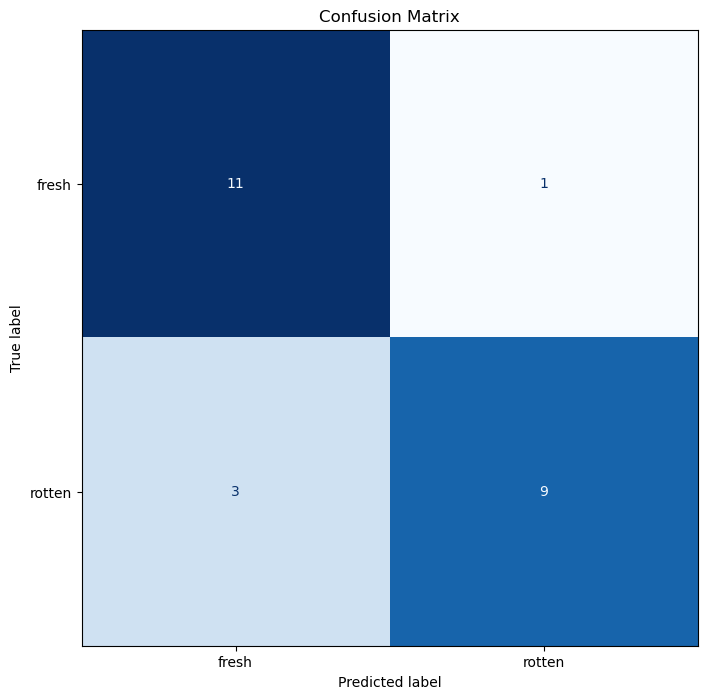


Evaluation Complete!


In [6]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ====================================
# Configuration
# ====================================

MODEL_PATH = "models/fruit_quality_model.h5"
RESULTS_DIR = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

# ====================================
# Load Model
# ====================================

print("Loading trained model...")

model = tf.keras.models.load_model(MODEL_PATH)

# ====================================
# Evaluate Model
# ====================================

loss, accuracy = model.evaluate(test_ds)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

# ====================================
# Predictions
# ====================================

y_true = []
y_pred = []

class_names = CLASS_NAMES

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ====================================
# Classification Report
# ====================================

print("\nClassification Report\n")

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

with open(
    os.path.join(RESULTS_DIR, "classification_report.txt"),
    "w"
) as f:

    f.write(report)

# ====================================
# Confusion Matrix
# ====================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.png"
    )
)

plt.show()

# ====================================
# Save Metrics
# ====================================

with open(
    os.path.join(
        RESULTS_DIR,
        "test_metrics.txt"
    ),
    "w"
) as f:

    f.write(f"Test Accuracy : {accuracy:.4f}\n")
    f.write(f"Test Loss     : {loss:.4f}\n")

print("\nEvaluation Complete!")

Loading Model...
Classes: ['fresh', 'rotten']

Prediction: rotten
Confidence: 70.07%


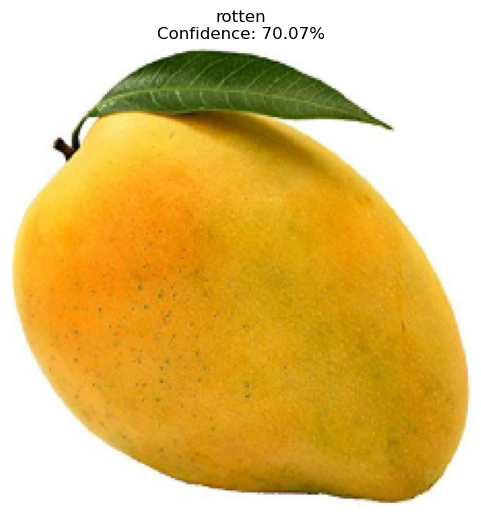

In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ======================================
# Configuration
# ======================================

MODEL_PATH = "models/fruit_quality_model.h5"

IMG_HEIGHT = 224
IMG_WIDTH = 224

# ======================================
# Load Model
# ======================================

print("Loading Model...")

model = tf.keras.models.load_model(MODEL_PATH)

# ======================================
# Load Class Names
# ======================================

train_dir = "dataset/train"

class_names = sorted(
    [
        folder
        for folder in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, folder))
    ]
)

print("Classes:", class_names)

# ======================================
# Prediction Function
# ======================================

def predict_image(image_path):

    img = image.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(predictions)

    confidence = np.max(predictions)

    predicted_class = class_names[predicted_index]

    return predicted_class, confidence, img

# ======================================
# Test Image
# ======================================

IMAGE_PATH = "sample_images/test9.jpg"

prediction, confidence, img = predict_image(IMAGE_PATH)

print("\nPrediction:", prediction)
print(f"Confidence: {confidence*100:.2f}%")

# ======================================
# Display Result
# ======================================

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.axis("off")

plt.title(
    f"{prediction}\nConfidence: {confidence*100:.2f}%"
)

plt.show()